In [1]:
import os, numpy as np
#Ensuring working directory is repo root
os.chdir("..")
print("CWD:", os.getcwd())
X_train = np.load("data/processed/X_train.npy")
X_test  = np.load("data/processed/X_test.npy")
y_train = np.load("data/processed/y_train.npy").astype(int)
y_test  = np.load("data/processed/y_test.npy").astype(int)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Default rate train:", y_train.mean(), "test:", y_test.mean())

CWD: /Users/laasyamadgula/Desktop/sta141c_final
X_train: (24000, 23) X_test: (6000, 23)
Default rate train: 0.22004166666666666 test: 0.22583333333333333


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

In [3]:
logistic_raw = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
]).fit(X_train, y_train)

logistic_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=141)),
    ("clf", LogisticRegression(max_iter=5000))
]).fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=141,
    class_weight="balanced"
).fit(X_train, y_train)

In [4]:
def get_preds(model, X, threshold=0.5):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return pred, prob

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
models = {
    "Logistic (raw)": logistic_raw,
    "Logistic + PCA": logistic_pca,
    "Random Forest": rf
}
rows = []
store = {}

for name, model in models.items():
    y_pred, y_prob = get_preds(model, X_test)
    m = compute_metrics(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    m["roc_auc"] = auc(fpr, tpr)
    rows.append({"model": name, **m})
    store[name] = {"y_pred": y_pred, "y_prob": y_prob, "fpr": fpr, "tpr": tpr}

metrics_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
metrics_df

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.814000,0.668073,0.350554,0.459826,0.774782
0,Logistic (raw),0.807167,0.727064,0.233948,0.353992,0.726720
1,Logistic + PCA,0.808833,0.735294,0.239852,0.361714,0.722240


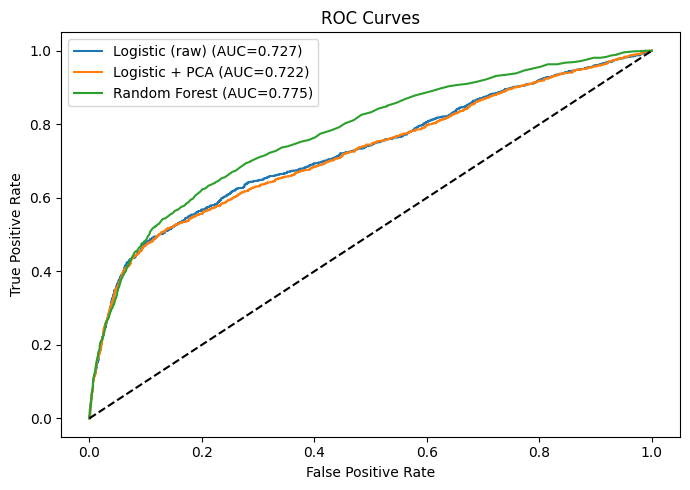

In [5]:
plt.figure(figsize=(7,5))
for name, d in store.items():
    roc_auc = auc(d["fpr"], d["tpr"])
    plt.plot(d["fpr"], d["tpr"], label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

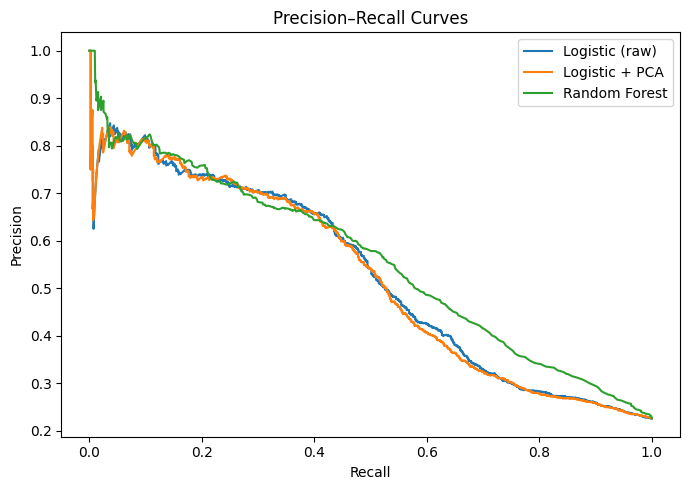

In [6]:
plt.figure(figsize=(7,5))
for name, d in store.items():
    prec, rec, _ = precision_recall_curve(y_test, d["y_prob"])
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

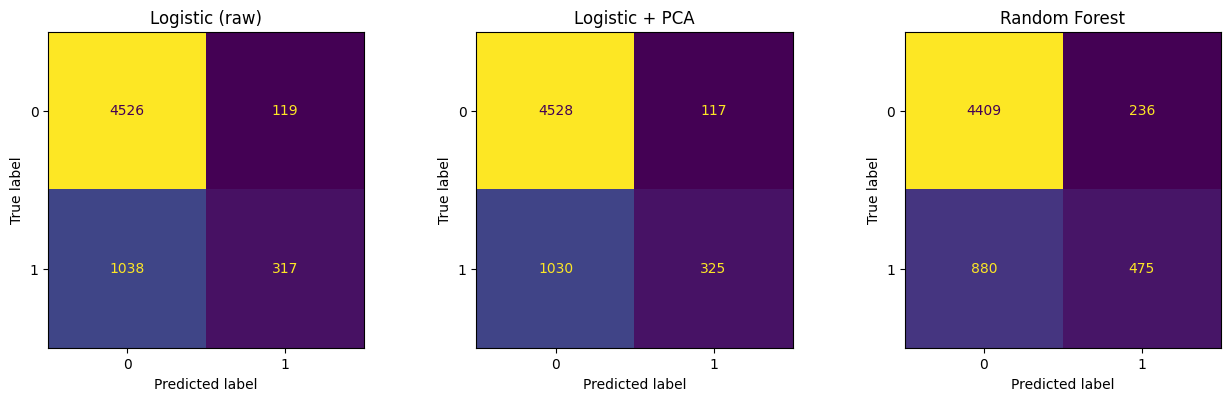

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, (name, d) in zip(axes, store.items()):
    cm = confusion_matrix(y_test, d["y_pred"])
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()